In [56]:
import numpy as np
import pandas as pd 

Reading the data

In [57]:
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [58]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

As we can observe that the features Age and Cabin has very high number of null values, so we must fill the null values of these features appropriately.

Extracting the mode of each features

In [59]:
modes = df.mode().iloc[0]
modes

PassengerId                      1
Survived                       0.0
Pclass                         3.0
Name           Abbing, Mr. Anthony
Sex                           male
Age                           24.0
SibSp                          0.0
Parch                          0.0
Ticket                        1601
Fare                          8.05
Cabin                      B96 B98
Embarked                         S
Name: 0, dtype: object

Filling the null values with the highest frequently occuring value for each features

In [60]:
df.fillna(modes,inplace=True)

In [61]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [62]:
df = df.rename(columns={i:i.lower() for i in df.columns})
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S


Studying the data

In [63]:
df.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,28.566970,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.199572,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,24.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: >

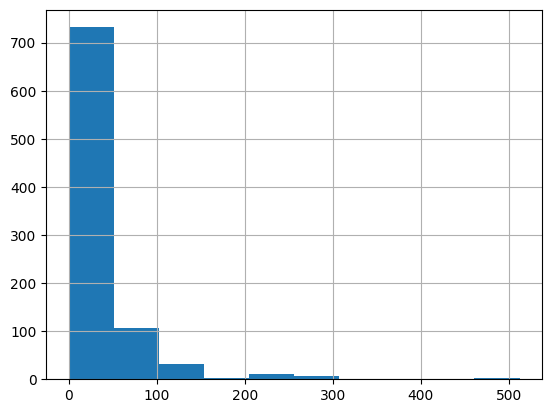

In [64]:
df['fare'].hist()

As we can observe from the above diagram that, the feature fare is right-tailed, which can bring inconsistency while training the model because the large outliers might dominate the small values. so we must apply the logarithm to the fare feature, which makes the data distribution symmetric that helps in the converging the cost function.

In [65]:
df['fare'] = np.log(df['fare'] + 1)
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,2.110213,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,4.280593,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.188856,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,3.990834,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,2.202765,B96 B98,S


In [66]:
def classify(df):
    target = 'survived'
    numerical = [c for c in df.select_dtypes(include=np.number).columns if c!=target]
    categorical = [c for c in df.select_dtypes(exclude=np.number).columns if c!=target]
    continuous = [feature for feature in numerical if df[feature].nunique()>20]
    discrete = [feature for feature in numerical if df[feature].nunique()<=20]
    return numerical, categorical, continuous, discrete
numerical, categorical, continuous, discrete = classify(df)


In [67]:
print('The numerical features are:', numerical)
print('The categorical features are:', categorical)
print()

The numerical features are: ['passengerid', 'pclass', 'age', 'sibsp', 'parch', 'fare']
The categorical features are: ['name', 'sex', 'ticket', 'cabin', 'embarked']



In [68]:
df = pd.get_dummies(df,columns=['sex','pclass','embarked'],dtype = int)

Dropping the unnecessary columns

In [69]:
df.head()

,passengerid,survived,name,age,sibsp,parch,ticket,fare,cabin,sex_female,sex_male,pclass_1,pclass_2,pclass_3,embarked_C,embarked_Q,embarked_S
0,1,0,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,2.110213,B96 B98,0,1,0,0,1,0,0,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,4.280593,C85,1,0,1,0,0,1,0,0
2,3,1,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,2.188856,B96 B98,1,0,0,0,1,0,0,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,3.990834,C123,1,0,1,0,0,0,0,1
4,5,0,"Allen, Mr. William Henry",35.0,0,0,373450,2.202765,B96 B98,0,1,0,0,1,0,0,1


In [70]:
indep_features = ['age','sibsp','parch','fare','sex_female','sex_male','pclass_1','pclass_2','pclass_3','embarked_C','embarked_Q','embarked_S']
dep_feature = ['survived']
